# Filtro pasa altos

1. Defina m ́ascaras de filtrado pasa-altos cuyos coeficientes sumen 1 y apl ́ıquelas
sobre diferentes im ́agenes. Interprete los resultados.
2. Repita el ejercicio anterior para m ́ascaras cuyos coeficientes sumen 0. Com-
pare los resultados con los del punto anterior

In [1]:
# Configuración Inicial e Importaciones
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
import ipywidgets as widgets


In [19]:
def comparar_imagenes(img_1, img_2, titulo_original="Original", titulo_filtrada="Filtrada"):
    fig, axs = plt.subplots(1,2, figsize=(10,5))
    axs[0].imshow(img_1, cmap="gray")
    axs[0].set_title(titulo_original)
    axs[0].axis("off")
    
    axs[1].imshow(img_2, cmap="gray")
    axs[1].set_title(titulo_filtrada)
    axs[1].axis("off")
    
    plt.tight_layout()
    plt.show()

def probar_realce(img, a):
    
    centro = 1 + 4*a
    
    mask = np.array([
        [0,  -a, 0],
        [-a, centro, -a],
        [0,  -a, 0]
    ], dtype=np.float32)
    
    print("Máscara:")
    print(mask)
    print("Suma:", mask.sum())
    
    img_filtrada = cv2.filter2D(img, -1, mask)
    
    comparar_imagenes(
        img,
        img_filtrada,
        "Original",
        f"Realce a={a:.1f}"
    )

def probar_realce_tamano(img, kernel_size, a):
    
    # matriz llena de -a
    mask = np.full((kernel_size, kernel_size), -a, dtype=np.float32)
    
    # centro
    centro = kernel_size // 2
    mask[centro, centro] = 1 + (kernel_size**2 - 1)*a
    
    print("Suma:", mask.sum())
    print(mask)
    
    img_filtrada = cv2.filter2D(img, -1, mask)
    
    comparar_imagenes(
        img,
        img_filtrada,
        "Original",
        f"Kernel {kernel_size}x{kernel_size}"
    )

def extraccion_interact(img,kernel_size, intensidad):
    
    # vecinos negativos
    mask = np.full(
        (kernel_size, kernel_size),
        -intensidad,
        dtype=np.float32
    )
    
    # centro para que suma = 0
    centro = kernel_size // 2
    mask[centro, centro] = (kernel_size**2 - 1) * intensidad
    
    print("Suma:", mask.sum())
    print(mask)
    
    img_filtrada = cv2.filter2D(
        img,
        -1,
        mask
    )
    
    comparar_imagenes(
        img,
        img_filtrada,
        "Original",
        f"Extracción {kernel_size}x{kernel_size}"
    )






# Realce
En el realce, el kernel suma 1, manteniendo las frecuencias de la imagen (mantiene el brillo de la imagen)

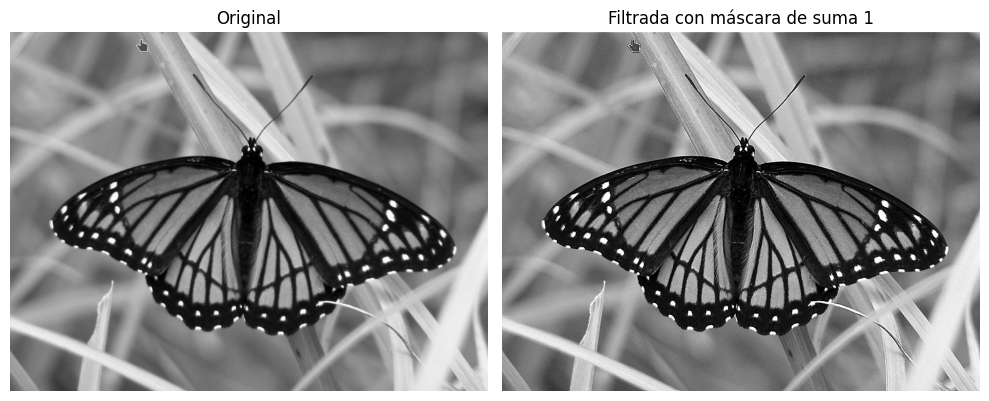

In [4]:
mask_sum_1= np.array(
    [[ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]], dtype=np.float32)

img = cv2.imread("../Imagenes_cursado/mariposa02.png", cv2.IMREAD_GRAYSCALE)

img_filtrada = cv2.filter2D(img, -1, mask_sum_1)

comparar_imagenes(img, img_filtrada, "Original", "Filtrada con máscara de suma 1")




Posibles modificaciones:
- Agrandar como avanza la matriz
- Pronunicar los valores negativos y positivos
Este codigo permite configurar los dos

In [8]:
interact(
    lambda kernel_size, a: probar_realce_tamano(img, kernel_size, a),
    kernel_size=IntSlider(
        value=3,
        min=3,
        max=11,
        step=2,   # solo impares
        description="Tamaño"
    ),
    a=FloatSlider(
        value=0.1,
        min=0.01,
        max=1.0,
        step=0.05,
        description="a"
    )
)

interactive(children=(IntSlider(value=3, description='Tamaño', max=11, min=3, step=2), FloatSlider(value=0.1, …

<function __main__.<lambda>(kernel_size, a)>

El valor da como resultado una imagen con brodes mas definidos sin perder brillo. COn mas textura.

El tamaño de la matriz


# 2. Extraccion pura

Si las matrices no suman 1, lo que tenemos es que la imagen ganara o perdera brillo. En particular, si ponemos suma=0 obtendremos los bordes de la imagen



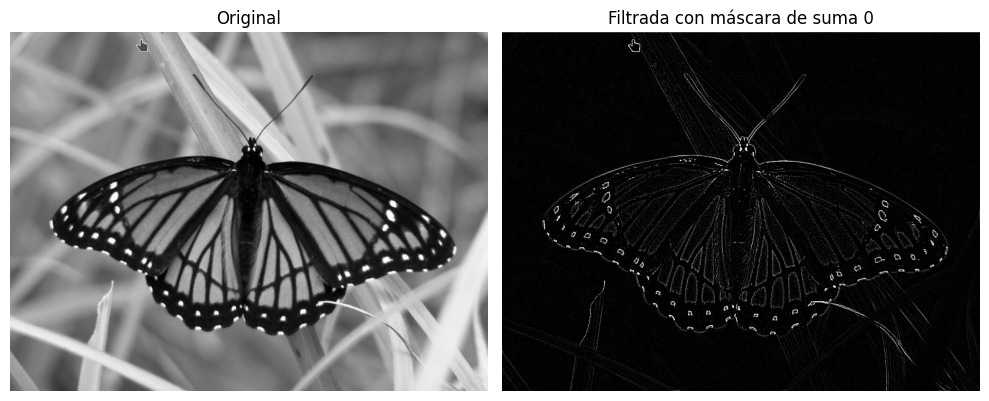

In [14]:
img = cv2.imread("../Imagenes_cursado/mariposa02.png", cv2.IMREAD_GRAYSCALE)

mask_sum0 = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]], dtype=np.float32)


img_filtrada_sum0 = cv2.filter2D(img, -1, mask_sum0)
comparar_imagenes(img, img_filtrada_sum0, "Original", "Filtrada con máscara de suma 0")

In [ ]:
interact(
    lambda kernel_size, intensidad: extraccion_interact(img, kernel_size, intensidad),
    kernel_size=IntSlider(
        value=3,
        min=3,
        max=11,
        step=2,
        description="Tamaño"
    ),
    
    intensidad=FloatSlider(
        value=1,
        min=0.1,
        max=10,
        step=0.1,
        description="Intensidad"
    )
)

interactive(children=(IntSlider(value=3, description='Tamaño', max=11, min=3, step=2), FloatSlider(value=1.0, …

<function __main__.<lambda>(kernel_size, intensidad)>